In [1]:
!dir

akshare\ convbonds\ analysis\ pandas.txt
data
docs
generate_annotations_with_malignancy.ipynb
his_git
jimmy_gan_minist_good.py
jimmy_pytorch_convertible_bond_value_analysis\ 202410.ipynb
jimmy_pytorch_convertible_bond_value_analysis.ipynb
jimmy_pytorch_notebook_all_commands.ipynb
jimmy_pytorch_sin_learn_plot
jimmy_pytorch_stock.ipynb
jimmy_test_F_TO_C_NN.ipynb
p1ch2
p1ch3
p1ch4
p1ch5
p1ch6
p1ch7
p1ch8
p2ch09
p2ch10
p2ch10_explore_data.ipynb
p2ch11
p2ch12
p2ch12_explore_data.ipynb
p2ch13
p2ch13_explore_data.ipynb
p2ch13_explore_data_v2.ipynb
p2ch13_explore_diagnose.ipynb
p2ch14
p2ch14_malben_baseline.ipynb
p2_run_everything.ipynb
p3ch15
README.md
requirements.txt
util


In [2]:
!git pull

Already up-to-date.


In [3]:
!git status -uno

# On branch master
# Changes not staged for commit:
#   (use "git add <file>..." to update what will be committed)
#   (use "git checkout -- <file>..." to discard changes in working directory)
#
#	modified:   jimmy_pytorch_notebook_all_commands.ipynb
#	modified:   jimmy_test_F_TO_C_NN.ipynb
#
no changes added to commit (use "git add" and/or "git commit -a")


In [4]:
!git log

commit c1c9ea874a2acca544f297ce25c9a3d5146f2040
Author: jimmy zhang <challengethink@gmail.com>
Date:   Sun Sep 29 16:04:46 2024 +0800

    20240930 conv bonds selection regression and notes

commit 88b444c9a039e2d8f7115df2f97908a2a8b6b262
Author: jimmy zhang <challengethink@gmail.com>
Date:   Sun Sep 29 16:03:37 2024 +0800

    20240930 conv bonds selection regression and notes

commit 4110805ff618cb5bf7920344168646487788764d
Author: jimmy zhang <challengethink@gmail.com>
Date:   Sun Sep 29 13:47:04 2024 +0800

    20240930 conv bonds selection regression and notes

commit c9b855fc7e6eb9f571ed4afee7c10b43ae0e8b28
Author: jimmy zhang <challengethink@gmail.com>
Date:   Tue Dec 5 14:01:30 2023 +0800

    modified pytorch_convertible_bond

commit 4722d686729331ca5b508cf60489bc2257626b89
Author: jimmy zhang <challengethink@gmail.com>
Date:   Wed Jun 7 21:40:19 2023 +0800

    add incremental scrapy convertible bond data.

commit 20df82902716d860f41faeec1d1aa644125f7335
Author: jimmy zhang <

In [5]:
%pwd

'/root/github_demo/pytorch-dlwpt-code'

In [6]:
!git pull
!pip install torch


Already up-to-date.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple

[notice] A new release of pip is available: 23.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [7]:
#begin  GAN sin function test.
# -*- coding: utf-8 -*-

import torch
import math


dtype = torch.float
device = torch.device("cpu")
# device = torch.device("cuda:0") # Uncomment this to run on GPU

# Create random input and output data
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)

# Randomly initialize weights
a = torch.randn((), device=device, dtype=dtype)
b = torch.randn((), device=device, dtype=dtype)
c = torch.randn((), device=device, dtype=dtype)
d = torch.randn((), device=device, dtype=dtype)

learning_rate = 1e-6
for t in range(2000):
    # Forward pass: compute predicted y
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss
    loss = (y_pred - y).pow(2).sum().item()
    if t % 100 == 99:
        print(t, loss)

    # Backprop to compute gradients of a, b, c, d with respect to loss
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()

    # Update weights using gradient descent
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d


print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')




99 3841.73291015625
199 2543.838134765625
299 1685.4581298828125
399 1117.74951171875
499 742.2781372070312
599 493.9451904296875
699 329.6978454589844
799 221.06295776367188
899 149.20953369140625
999 101.6834716796875
1099 70.24754333496094
1199 49.45409393310547
1299 35.699642181396484
1399 26.601177215576172
1499 20.582515716552734
1599 16.601016998291016
1699 13.967058181762695
1799 12.224535942077637
1899 11.071700096130371
1999 10.30896282196045
Result: y = 0.004132617264986038 + 0.8193874955177307 x + -0.0007129444275051355 x^2 + -0.08801720291376114 x^3


99 220.8855438232422
199 150.20436096191406
299 103.12840270996094
399 71.76002502441406
499 50.84824752807617
599 36.90031814575195
699 27.592525482177734
799 21.377662658691406
899 17.22564697265625
999 14.45008373260498
1099 12.593432426452637
1199 11.350678443908691
1299 10.518232345581055
1399 9.960250854492188
1499 9.585929870605469
1599 9.334650039672852
1699 9.165823936462402
1799 9.052292823791504
1899 8.975883483886719
1999 8.92441177368164
Result: y = 0.006257513538002968 + 0.8484755158424377 x + -0.0010795251000672579 x^2 + -0.09215471893548965 x^3


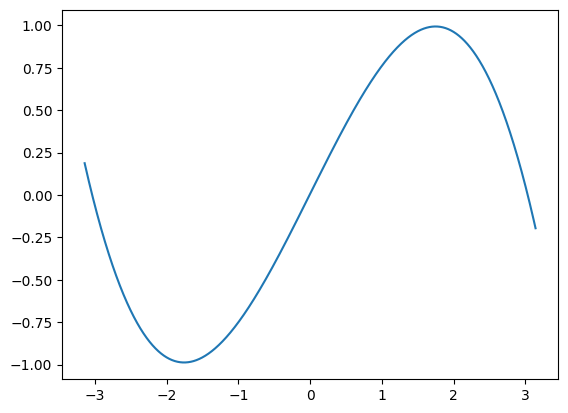

In [8]:


#exampe2 auto grad ---------------




# -*- coding: utf-8 -*-
#import torch
#import math

import matplotlib.pyplot as plt

# Create Tensors to hold input and outputs.
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)

# For this example, the output y is a linear function of (x, x^2, x^3), so
# we can consider it as a linear layer neural network. Let's prepare the
# tensor (x, x^2, x^3).
p = torch.tensor([1, 2, 3])
xx = x.unsqueeze(-1).pow(p)

# In the above code, x.unsqueeze(-1) has shape (2000, 1), and p has shape
# (3,), for this case, broadcasting semantics will apply to obtain a tensor
# of shape (2000, 3) 

# Use the nn package to define our model as a sequence of layers. nn.Sequential
# is a Module which contains other Modules, and applies them in sequence to
# produce its output. The Linear Module computes output from input using a
# linear function, and holds internal Tensors for its weight and bias.
# The Flatten layer flatens the output of the linear layer to a 1D tensor,
# to match the shape of `y`.
model = torch.nn.Sequential(
    torch.nn.Linear(3, 1),
    torch.nn.Flatten(0, 1)
)

# The nn package also contains definitions of popular loss functions; in this
# case we will use Mean Squared Error (MSE) as our loss function.
loss_fn = torch.nn.MSELoss(reduction='sum')

learning_rate = 1e-6
for t in range(2000):

    # Forward pass: compute predicted y by passing x to the model. Module objects
    # override the __call__ operator so you can call them like functions. When
    # doing so you pass a Tensor of input data to the Module and it produces
    # a Tensor of output data.
    y_pred = model(xx)

    # Compute and print loss. We pass Tensors containing the predicted and true
    # values of y, and the loss function returns a Tensor containing the
    # loss.
    loss = loss_fn(y_pred, y)
    if t % 100 == 99:
        print(t, loss.item())

    # Zero the gradients before running the backward pass.
    model.zero_grad()

    # Backward pass: compute gradient of the loss with respect to all the learnable
    # parameters of the model. Internally, the parameters of each Module are stored
    # in Tensors with requires_grad=True, so this call will compute gradients for
    # all learnable parameters in the model.
    loss.backward()

    # Update the weights using gradient descent. Each parameter is a Tensor, so
    # we can access its gradients like we did before.
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad

# You can access the first layer of `model` like accessing the first item of a list
linear_layer = model[0]

# For linear layer, its parameters are stored as `weight` and `bias`.
print(f'Result: y = {linear_layer.bias.item()} + {linear_layer.weight[:, 0].item()} x + {linear_layer.weight[:, 1].item()} x^2 + {linear_layer.weight[:, 2].item()} x^3')


#plt.plot(x, y)  # Works now
#plt.show()
y_model = model(xx)
y_model = y_model.detach().numpy()
plt.plot(x, y_model)  # Works now
plt.show()

#https://blog.csdn.net/pylittlebrat/article/details/124473882


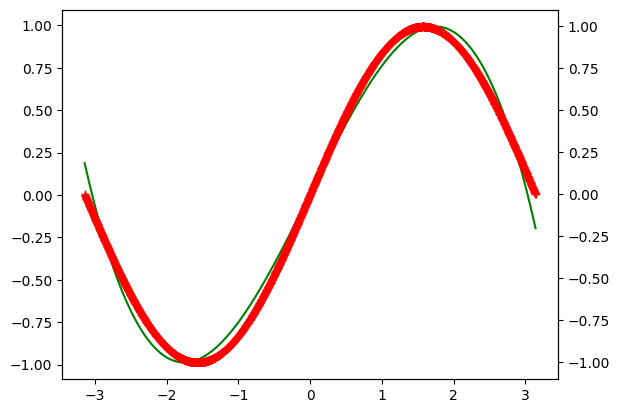

In [9]:
#plt.plot(x, y)  # Works now
#plt.show()
#y_model = model(xx)
#y_model = y_model.detach().numpy()
#plt.plot(x, y_model)  # Works now
#plt.show()

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()    #使用twinx添加y轴的坐标轴
ax1.plot(x, y_model, 'g-')
ax2.plot(x, y, 'r+')
plt.show()

In [10]:
%matplotlib inline
import numpy as np
import torch
import torch.optim as optim

torch.set_printoptions(edgeitems=2, linewidth=75)

In [11]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c).unsqueeze(1) # <1>
t_u = torch.tensor(t_u).unsqueeze(1) # <1>

t_u.shape

torch.Size([11, 1])

In [12]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 9,  7,  0,  5, 10,  6,  4,  8,  1]), tensor([3, 2]))

In [13]:
t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [14]:
import torch.nn as nn

linear_model = nn.Linear(1, 1) # <1>
linear_model(t_un_val)

tensor([[-3.8732],
        [-2.8621]], grad_fn=<AddmmBackward0>)

In [15]:
linear_model.weight

Parameter containing:
tensor([[-0.4266]], requires_grad=True)

In [16]:
linear_model.bias

Parameter containing:
tensor([-0.3793], requires_grad=True)

In [17]:
x = torch.ones(1)
linear_model(x)

tensor([-0.8059], grad_fn=<ViewBackward0>)

In [18]:
x = torch.ones(10, 1)
linear_model(x)

tensor([[-0.8059],
        [-0.8059],
        [-0.8059],
        [-0.8059],
        [-0.8059],
        [-0.8059],
        [-0.8059],
        [-0.8059],
        [-0.8059],
        [-0.8059]], grad_fn=<AddmmBackward0>)

In [19]:
linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(
    linear_model.parameters(), # <2>
    lr=1e-2)

In [20]:
linear_model.parameters()

<generator object Module.parameters at 0x7f389f080f90>

In [21]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[-0.2646]], requires_grad=True),
 Parameter containing:
 tensor([-0.9976], requires_grad=True)]

In [22]:
def training_loop(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val,
                  t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train) # <1>
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val) # <1>
        loss_val = loss_fn(t_p_val, t_c_val)
        
        optimizer.zero_grad()
        loss_train.backward() # <2>
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")


In [23]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

linear_model = nn.Linear(1, 1) # <1>
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 3000, 
    optimizer = optimizer,
    model = linear_model,
    loss_fn = loss_fn,
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 195.0554, Validation loss 757.6900
Epoch 1000, Training loss 4.1195, Validation loss 14.7254
Epoch 2000, Training loss 3.0288, Validation loss 6.8022
Epoch 3000, Training loss 2.9753, Validation loss 5.4797

Parameter containing:
tensor([[5.0033]], requires_grad=True)
Parameter containing:
tensor([-15.8185], requires_grad=True)


In [24]:
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs = 3000, 
    optimizer = optimizer,
    model = linear_model,
    loss_fn = nn.MSELoss(), # <1>
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 130.8359, Validation loss 553.4363
Epoch 1000, Training loss 4.0513, Validation loss 14.3583
Epoch 2000, Training loss 3.0255, Validation loss 6.7479
Epoch 3000, Training loss 2.9751, Validation loss 5.4691

Parameter containing:
tensor([[5.0044]], requires_grad=True)
Parameter containing:
tensor([-15.8242], requires_grad=True)


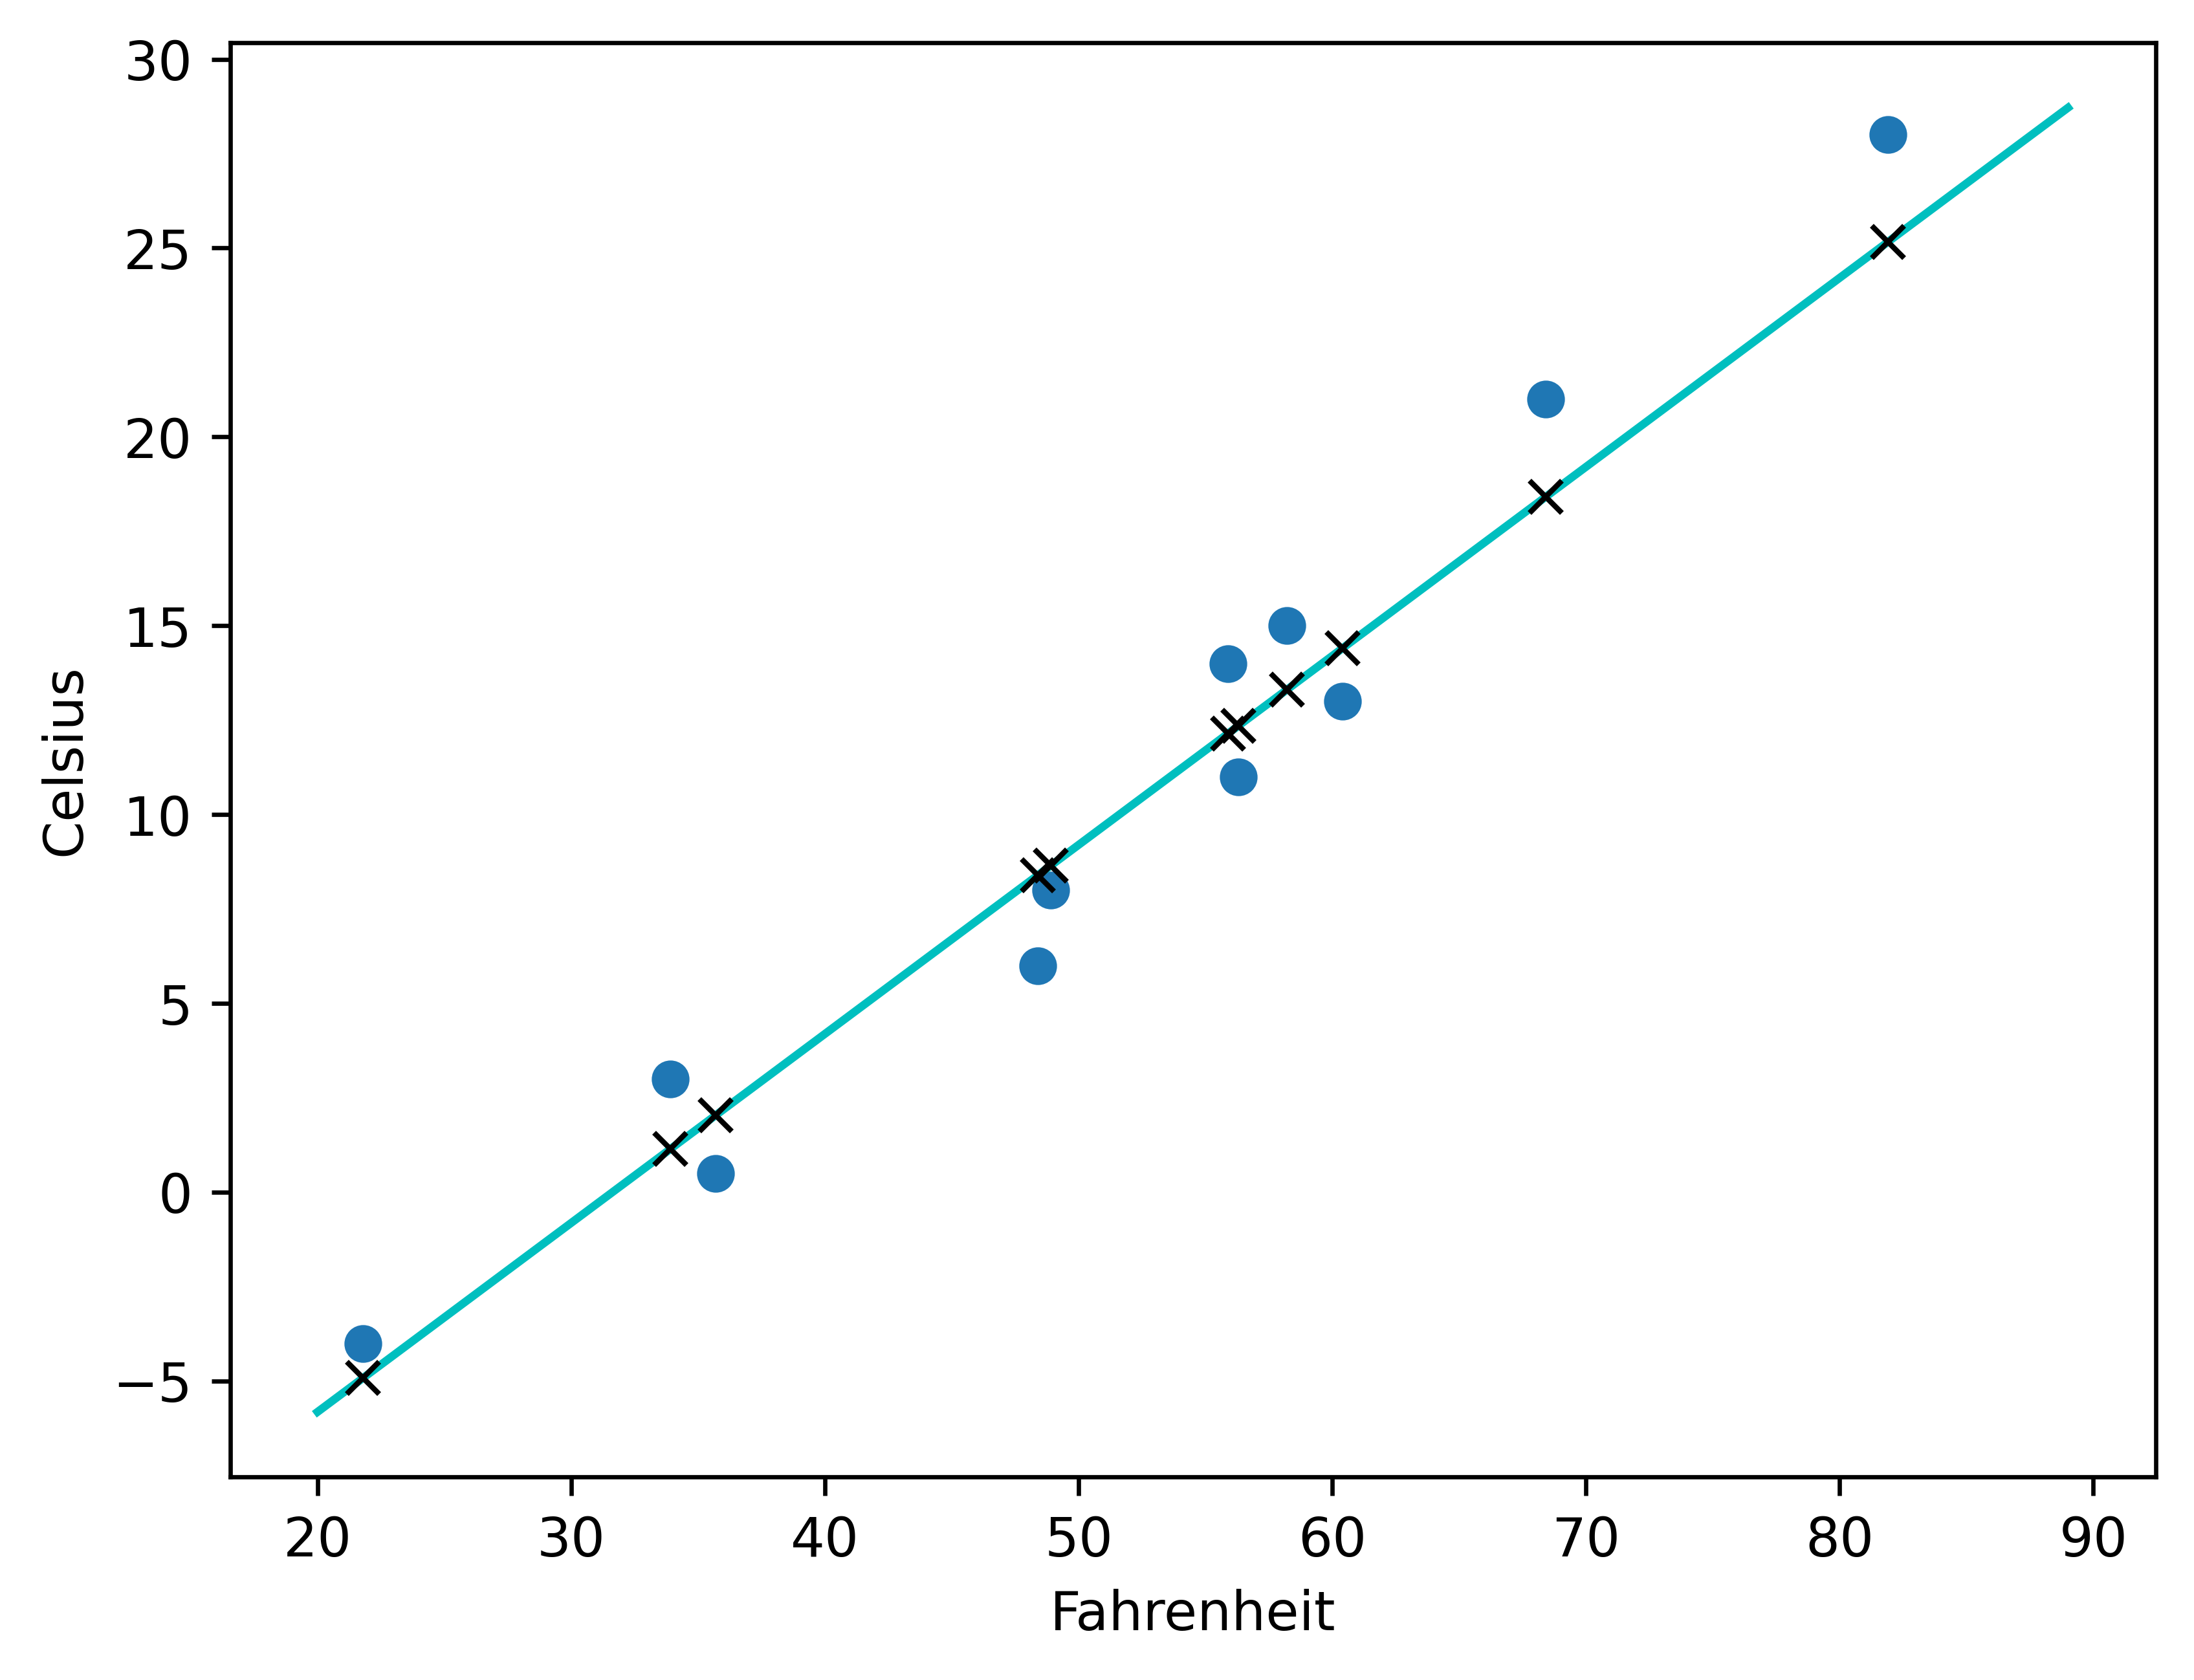

In [25]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), linear_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), linear_model(0.1 * t_u).detach().numpy(), 'kx')


In [26]:
seq_model = nn.Sequential(
            nn.Linear(1, 13), # <1>
            nn.Tanh(),
            nn.Linear(13, 1)) # <2>
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [27]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [28]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [29]:
from collections import OrderedDict

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, 8)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(8, 1))
]))

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [30]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [31]:
seq_model.output_linear.bias

Parameter containing:
tensor([-0.0243], requires_grad=True)

In [32]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3) # <1>

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)
    
print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 126.7361, Validation loss 532.5353
Epoch 1000, Training loss 5.0084, Validation loss 54.3919
Epoch 2000, Training loss 3.2563, Validation loss 29.2397
Epoch 3000, Training loss 2.6091, Validation loss 18.7408
Epoch 4000, Training loss 2.3153, Validation loss 12.9913
Epoch 5000, Training loss 2.1678, Validation loss 9.7038
output tensor([[23.8972],
        [13.3970]], grad_fn=<AddmmBackward0>)
answer tensor([[28.],
        [15.]])
hidden tensor([[-0.0072],
        [-0.0068],
        [ 0.0058],
        [-0.0151],
        [-0.0111],
        [ 0.0094],
        [-0.0326],
        [ 0.0002]])


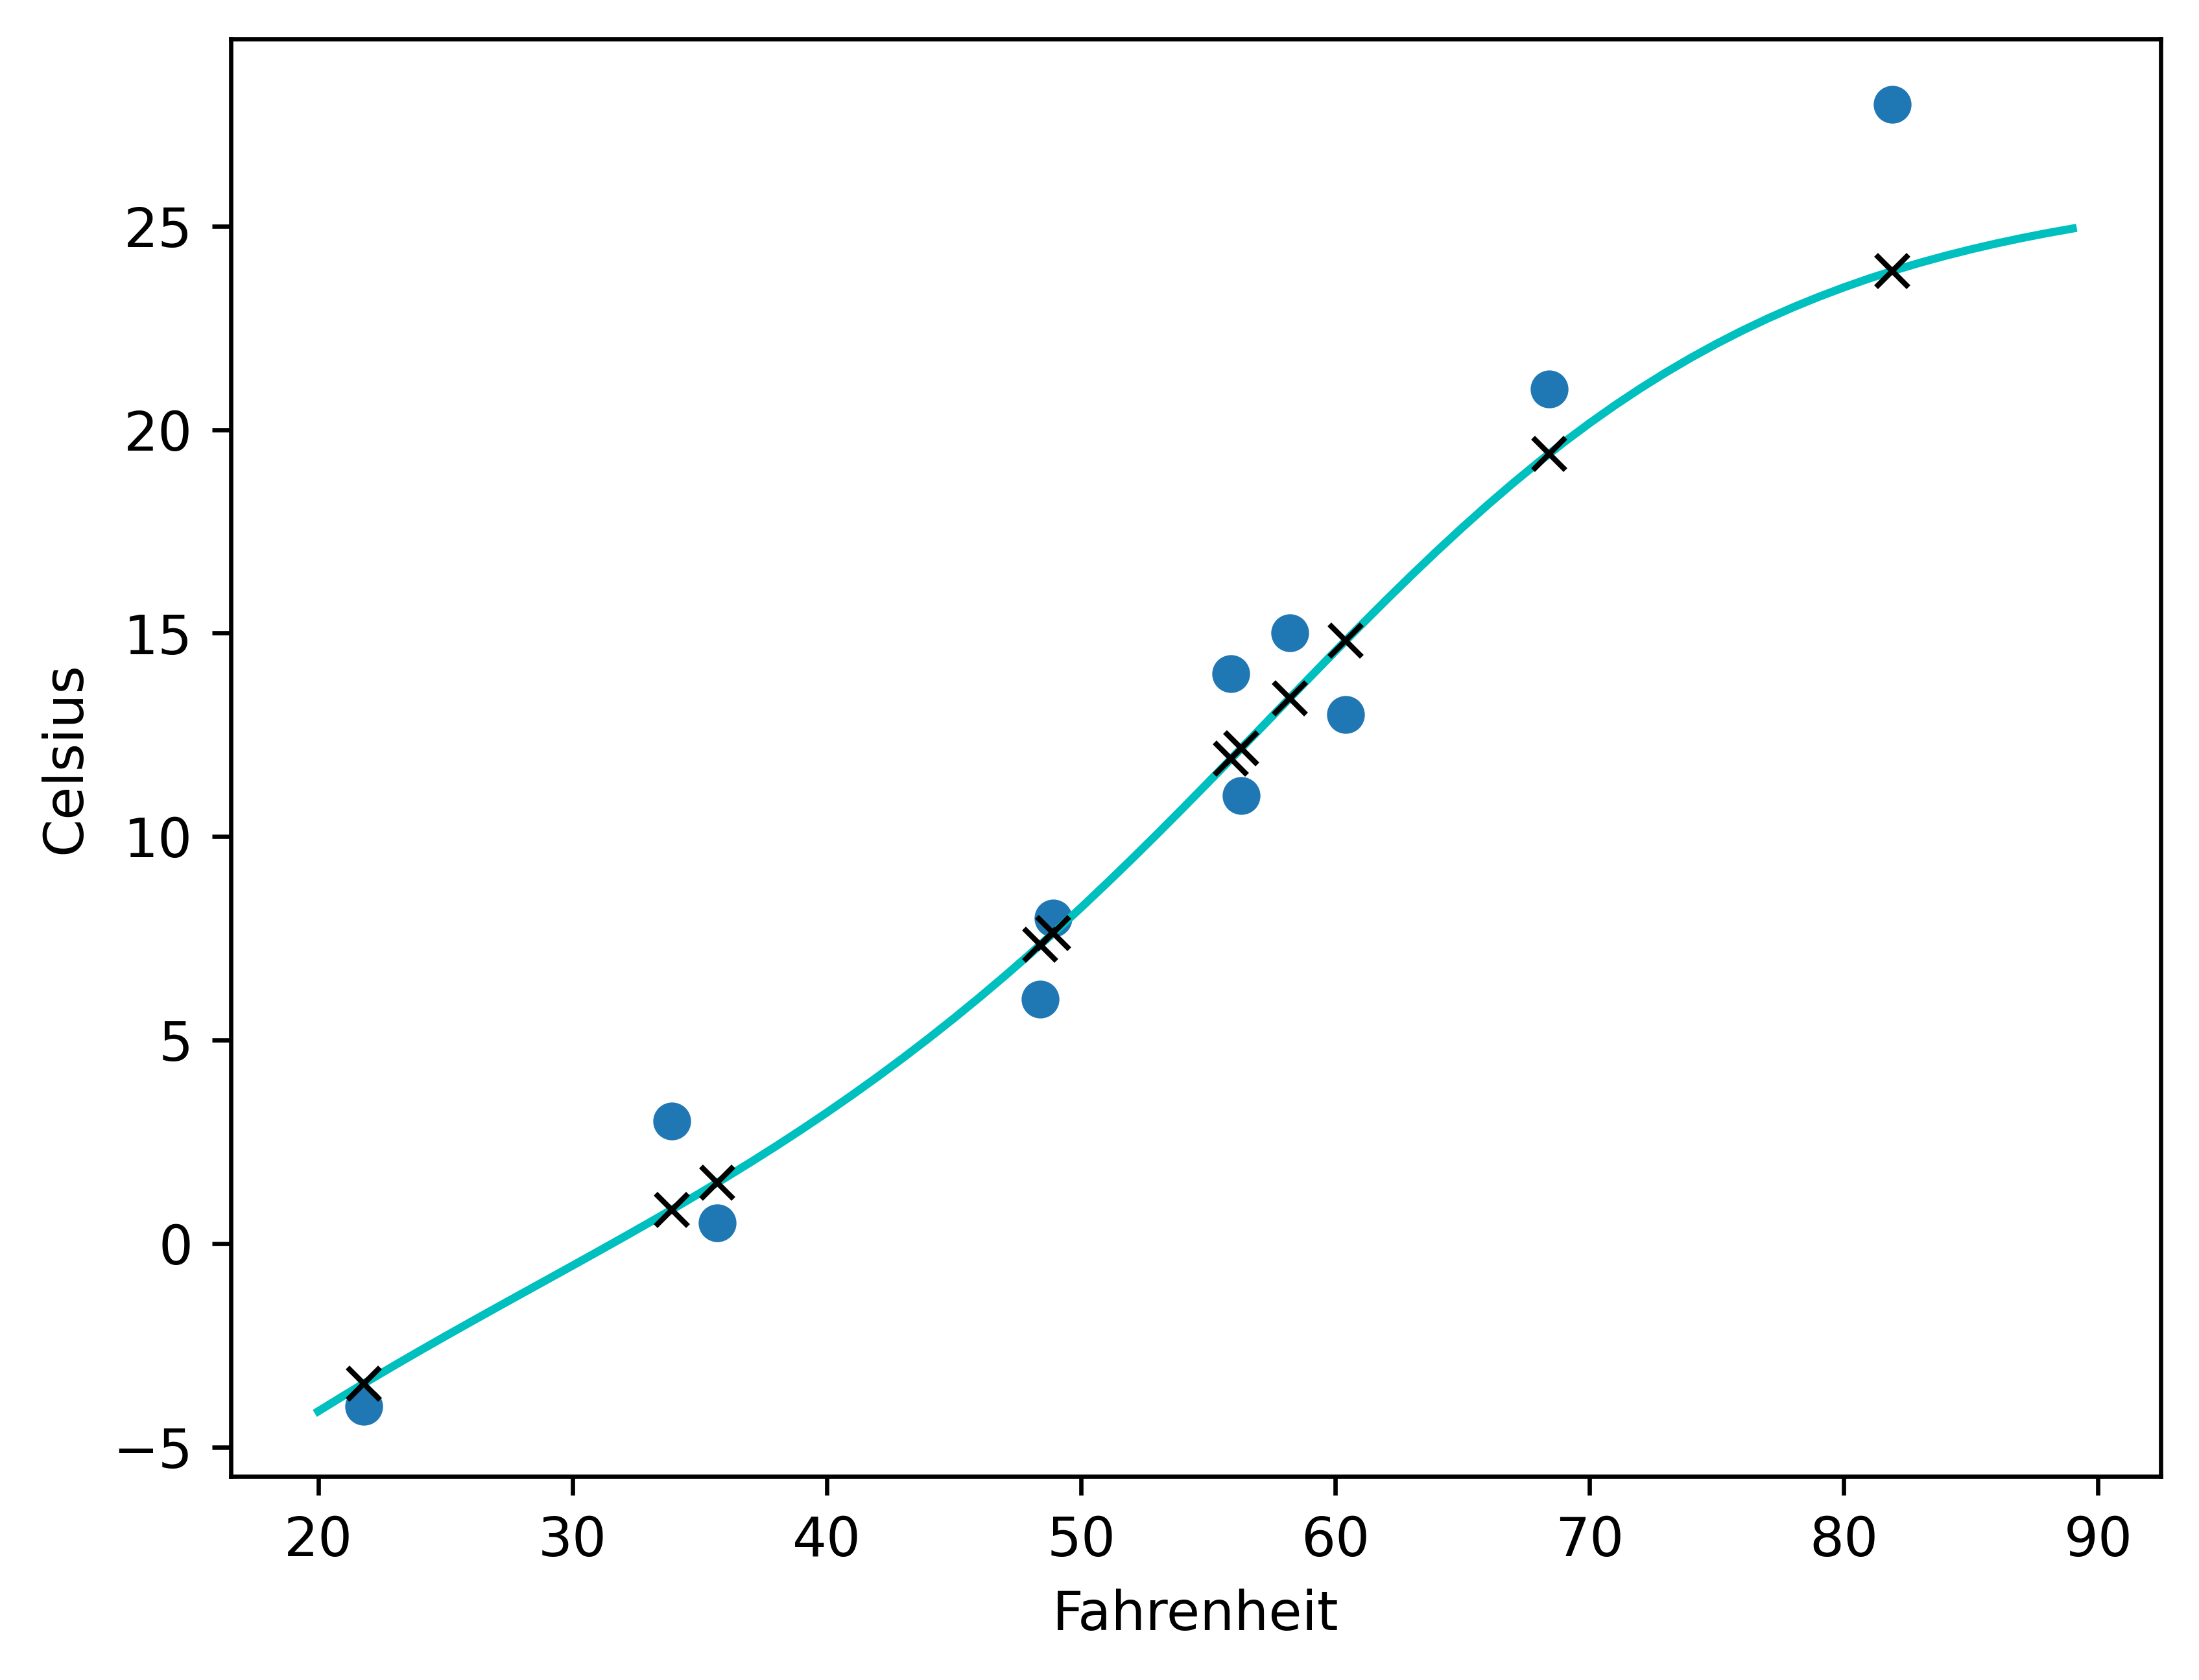

In [33]:
from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=600)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')


Epoch 1, Training loss 118.9623, Validation loss 508.8762
Epoch 1000, Training loss 40.4267, Validation loss 198.1739
Epoch 2000, Training loss 32.4751, Validation loss 164.8781
Epoch 3000, Training loss 24.5519, Validation loss 139.2887
Epoch 4000, Training loss 17.4735, Validation loss 115.1665
Epoch 5000, Training loss 12.1449, Validation loss 94.2054


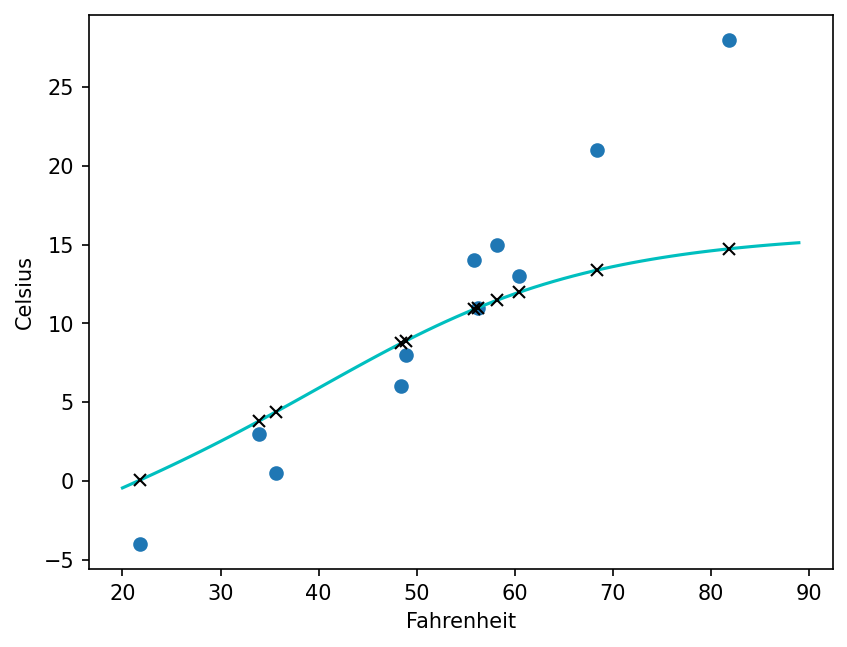

In [34]:
# Exercises here!

neuron_count = 20

seq_model = nn.Sequential(OrderedDict([
    ('hidden_linear', nn.Linear(1, neuron_count)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(neuron_count, 1))
]))

optimizer = optim.SGD(seq_model.parameters(), lr=1e-4)

training_loop(
    n_epochs = 5000, 
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val, 
    t_c_train = t_c_train,
    t_c_val = t_c_val)

from matplotlib import pyplot as plt

t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=150)
plt.xlabel("Fahrenheit")
plt.ylabel("Celsius")
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')
